# DSI-CL: 25K BBC News — Atomic vs Semantic vs Chrono-Semantic DocIDs + Continual Learning

## Dataset
- **BBC News AllTime**: 25,070 articles (Jan 2023 — Jul 2024)
- **Training set**: 20,415 docs across 16 months (T0–T15)
- **CL set**: 4,655 docs across 3 months (T16–T18) — held out for continual learning
- **Queries**: 10 training queries + 1 eval query per document (Gemini 2.5 Flash)

## Three DocID Experiments
- **Exp A (Atomic Baseline):** Random fixed DocIDs — no structure, no meaning
- **Exp B (Semantic RQ):** FAISS RQ codes — semantically similar docs get similar IDs
- **Exp C (Chrono-Semantic):** Task prefix + RQ codes — temporal structure on top of semantic

## Continual Learning Phase
After training on T0–T15, we incrementally add T16–T18 and measure:
- Backward transfer (forgetting on old tasks)
- Forward transfer (accuracy on new tasks)
- Per-month accuracy breakdown across DocID schemes


## 0. Setup

In [ ]:
# ============================================================

# 0A. Clone repo

# ============================================================

import os



REPO_URL = "https://github.com/YuvalShemla/DSI-news.git"

REPO_DIR = "/content/DSI-CL"



if not os.path.exists(REPO_DIR):

    !git clone {REPO_URL} {REPO_DIR}

    print(f"Cloned repo to {REPO_DIR}")

else:

    !cd {REPO_DIR} && git pull

    print(f"Repo already exists at {REPO_DIR}")



os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")

Already up to date.
Repo already exists at /content/DSI-CL
Working directory: /content/DSI-CL


In [ ]:
# ============================================================

# 0B. Install dependencies

# ============================================================

!pip install -q transformers>=4.51.0 peft>=0.15.0 faiss-cpu>=1.8.0 \

    accelerate pytrec_eval pyyaml ujson sentencepiece \

    matplotlib seaborn 2>&1 | tail -3



import transformers, peft, torch, faiss

print(f"transformers: {transformers.__version__}")

print(f"peft:          {peft.__version__}")

print(f"torch:         {torch.__version__}")

print(f"CUDA:          {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

transformers: 5.0.0
peft:          0.18.1
torch:         2.10.0+cu128
CUDA:          True — NVIDIA A100-SXM4-80GB


In [ ]:
# ============================================================

# 0C. HuggingFace login (Gemma license required)

# ============================================================

from huggingface_hub import login

from google.colab import userdata



try:

    hf_token = userdata.get('HF_TOKEN')

    login(token=hf_token)

    print("Logged in via Colab secret")

except Exception:

    print("Set HF_TOKEN in Colab secrets, or run: huggingface-cli login")

    login()

Logged in via Colab secret


In [ ]:
# ============================================================
# 0D. Global config
# ============================================================
import copy, gc, json, logging, random, warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger('poc')

MODEL_NAME = "google/t5gemma-2-270m-270m"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

# --- DocID params ---
# 6 bits = 64 centroids per codebook. With 4 codebooks: 64^4 = 16,777,216 possible IDs.
# For 20K docs: ~0.12% occupancy -> near-zero collisions.
NUM_RQ_CODEBOOKS = 4
RQ_NBITS = 6
RQ_CODEBOOK_SIZE = 2 ** RQ_NBITS  # 64

# Task IDs: each month is a task (T0-T18)
NUM_TASKS = 19
NUM_TRAIN_TASKS = 16  # T0-T15
NUM_CL_TASKS = 3      # T16-T18

DOCID_LEN_ATOMIC = NUM_RQ_CODEBOOKS            # Exp A: 4 tokens (random)
DOCID_LEN_RQ = NUM_RQ_CODEBOOKS                # Exp B: 4 tokens (semantic)
DOCID_LEN_CHRONO = 1 + NUM_RQ_CODEBOOKS        # Exp C: 5 tokens (task prefix + semantic)

# --- Training params ---
LORA_R = 32
LORA_ALPHA = 64
LEARNING_RATE = 1e-3
# ============================================================
# MODE: "lightweight" or "full"
# lightweight: 32 epochs, 5 queries/doc, eval 1000 docs  (~3 hrs on H100)
# full:        32 epochs, 10 queries/doc, eval 1000 docs (~3 hrs on H100)
# ============================================================
MODE = "lightweight"

NUM_EPOCHS = 32 if MODE == "lightweight" else 32
BATCH_SIZE = 256    # H100 has 80GB VRAM, can push large batches
MAX_QUERY_LEN = 96
CONVERGENCE_THRESHOLD = 0.01

# Query selection: lightweight uses 5 types, full uses all 10
TRAIN_QUERY_TYPES_LIGHT = ['KEYWORD_1', 'QUESTION_1', 'QUESTION_2', 'TOPICAL_1', 'BACKGROUND_1']
TRAIN_QUERY_TYPES_FULL = None  # None = use all

# --- Eval params ---
NUM_BEAMS = RQ_CODEBOOK_SIZE
EVAL_SAMPLE = 1000    # eval on 1000 random docs (plenty for reliable metrics)

QUERIES_PATH = Path("data/queries/bbc_25k_queries.csv")
METADATA_PATH = Path("data/queries/bbc_25k_metadata.csv")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print(f"Device: {DEVICE}")
print(f"DocID lengths: Atomic={DOCID_LEN_ATOMIC}, RQ={DOCID_LEN_RQ}, Chrono={DOCID_LEN_CHRONO}")
print(f"RQ: {NUM_RQ_CODEBOOKS} codebooks x {RQ_CODEBOOK_SIZE} centroids = {RQ_CODEBOOK_SIZE**NUM_RQ_CODEBOOKS:,} possible IDs")
print(f"Tasks: {NUM_TASKS} total ({NUM_TRAIN_TASKS} train + {NUM_CL_TASKS} CL)")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, lr={LEARNING_RATE}")


---
## 1. Dataset Exploration & Visualization

BBC News AllTime — 25,070 articles from Jan 2023 to Jul 2024.
Each document has 10 diverse training queries + 1 evaluation (ground truth) query.


In [ ]:
# ============================================================
# 1A. Load data & basic stats
# ============================================================
# Load queries (28MB) and metadata (90MB) separately — much smaller than the merged 1GB file
queries_df = pd.read_csv("data/queries/bbc_25k_queries.csv")
meta = pd.read_csv(METADATA_PATH)

# Build the combined dataframe for compatibility
df = queries_df.copy()

print(f"Total query-doc rows: {len(df):,}")
print(f"Unique documents: {df['doc_id'].nunique():,}")
print(f"Query types: {df['query_type'].value_counts().to_dict()}")
print(f"Splits: {df['split'].value_counts().to_dict()}")
print(f"\nPhase breakdown:")
print(f"  Training (T0-T15): {meta[meta['phase']=='train']['doc_id'].nunique():,} docs")
print(f"  CL (T16-T18):      {meta[meta['phase']=='cl']['doc_id'].nunique():,} docs")

In [ ]:
# ============================================================
# 1B. Monthly distribution bar chart
# ============================================================
task_counts = meta.groupby(['task_id', 'year_month', 'phase']).size().reset_index(name='count')
task_counts = task_counts.sort_values('task_id')

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#4C72B0' if p == 'train' else '#DD8452' for p in task_counts['phase']]
bars = ax.bar(range(len(task_counts)), task_counts['count'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_xticks(range(len(task_counts)))
ax.set_xticklabels([f"T{t}\n{ym}" for t, ym in zip(task_counts['task_id'], task_counts['year_month'])],
                    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Documents')
ax.set_title('BBC News 25K Dataset — Documents per Month')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C72B0', label='Training (T0-T15)'),
                   Patch(color='#DD8452', label='Continual Learning (T16-T18)')],
          loc='upper left')

# Add count labels on bars
for bar, count in zip(bars, task_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=8)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTotal train docs: {task_counts[task_counts['phase']=='train']['count'].sum():,}")
print(f"Total CL docs: {task_counts[task_counts['phase']=='cl']['count'].sum():,}")


In [ ]:
# ============================================================
# 1C. Sample documents & queries
# ============================================================
# Show 5 sample documents with their queries
sample_docs = meta.sample(5, random_state=42)
for _, doc_row in sample_docs.iterrows():
    doc_id = doc_row['doc_id']
    doc_queries = df[df['doc_id'] == doc_id]

    print(f"{'='*80}")
    print(f"Doc: {doc_id} | Task: T{doc_row['task_id']} ({doc_row['year_month']}) | Section: {doc_row['section']}")
    print(f"Title: {doc_row['title']}")
    print(f"Content: {str(doc_row['content'])[:300]}...")
    print()

    # Training queries
    train_qs = doc_queries[doc_queries['split'] == 'train'].sort_values('query_type')
    for _, qr in train_qs.iterrows():
        print(f"  [TRAIN] {qr['query_type']:13s}: {qr['query']}")

    # Eval query (ground truth)
    eval_qs = doc_queries[doc_queries['split'] == 'eval']
    if len(eval_qs) > 0:
        print(f"  [EVAL]  {'GROUND TRUTH':13s}: {eval_qs.iloc[0]['query']}")
    print()


In [ ]:
# ============================================================
# 1D. Query type distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Query type counts
qt_counts = df['query_type'].value_counts().sort_index()
colors_qt = ['#4C72B0'] * 10 + ['#C44E52']  # red for EVAL
axes[0].barh(qt_counts.index, qt_counts.values, color=colors_qt[:len(qt_counts)])
axes[0].set_xlabel('Count')
axes[0].set_title('Query Type Distribution')
axes[0].grid(True, alpha=0.3, axis='x')

# Query length distribution by type
df['query_len'] = df['query'].str.split().str.len()
query_types = sorted(df['query_type'].unique())
data_for_box = [df[df['query_type'] == qt]['query_len'].values for qt in query_types]
bp = axes[1].boxplot(data_for_box, labels=query_types, vert=False, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_qt[:len(query_types)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xlabel('Query Length (words)')
axes[1].set_title('Query Length by Type')
axes[1].grid(True, alpha=0.3, axis='x')
plt.setp(axes[1].get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()


---
## 2. Load Data & Train/Test Split


In [ ]:
# ============================================================
# 2A. Build corpus and splits
# ============================================================
# For the initial training phase, use only training documents (T0-T15)
# CL documents (T16-T18) are held out for the continual learning phase

# Build corpus: one row per unique document
train_meta = meta[meta['phase'] == 'train'].copy()
cl_meta = meta[meta['phase'] == 'cl'].copy()

# Corpus for initial training
docs_df = train_meta[['doc_id', 'task_id', 'year_month', 'title', 'content', 'date']].reset_index(drop=True)
print(f"Training corpus: {len(docs_df)} documents across {docs_df['task_id'].nunique()} tasks")

# CL corpus (for later)
cl_docs_df = cl_meta[['doc_id', 'task_id', 'year_month', 'title', 'content', 'date']].reset_index(drop=True)
print(f"CL corpus: {len(cl_docs_df)} documents across {cl_docs_df['task_id'].nunique()} tasks")

# Train/test split based on MODE
# Training: use training queries (filtered by MODE)
# Test: use eval (ground truth) queries — 1 per doc, never seen during training
all_train_queries = df[(df['split'] == 'train') & (df['phase'] == 'train')]
if MODE == "lightweight":
    train_queries_df = all_train_queries[all_train_queries['query_type'].isin(TRAIN_QUERY_TYPES_LIGHT)].reset_index(drop=True)
    print(f"Lightweight mode: using {len(TRAIN_QUERY_TYPES_LIGHT)} query types")
else:
    train_queries_df = all_train_queries.reset_index(drop=True)
    print(f"Full mode: using all {all_train_queries['query_type'].nunique()} query types")

# Test queries: ground truth (1 per doc, unseen during training)
test_queries_df = df[(df['split'] == 'eval') & (df['phase'] == 'train')].reset_index(drop=True)

# For train-set evaluation: sample 1 random training query per doc from 1000 random docs
eval_train_doc_ids = train_queries_df['doc_id'].drop_duplicates().sample(min(EVAL_SAMPLE, train_queries_df['doc_id'].nunique()), random_state=SEED)
eval_train_queries_df = train_queries_df[train_queries_df['doc_id'].isin(eval_train_doc_ids)].groupby('doc_id').sample(1, random_state=SEED).reset_index(drop=True)

# For test-set evaluation: sample 1000 random docs (already 1 query per doc)
eval_test_queries_df = test_queries_df.sample(min(EVAL_SAMPLE, len(test_queries_df)), random_state=SEED).reset_index(drop=True)

print(f"\nTraining queries: {len(train_queries_df):,} ({train_queries_df['query_type'].nunique()} types, {train_queries_df['doc_id'].nunique():,} docs)")
print(f"Eval (train accuracy): {len(eval_train_queries_df):,} queries (1 per doc, {eval_train_queries_df['doc_id'].nunique()} sampled docs)")
print(f"Eval (test accuracy):  {len(eval_test_queries_df):,} queries (ground truth, {eval_test_queries_df['doc_id'].nunique()} sampled docs)")


---
## 3. Load T5Gemma 2

In [ ]:
# ============================================================

# 2A. Load model + discover LoRA targets

# ============================================================

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer



print(f"Loading {MODEL_NAME}...")

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)



# Find attention projection layers for LoRA.

# IMPORTANT: we match exactly q/k/v/o_proj. NOT out_proj — that's the lm_head

# output layer, and with tie_word_embeddings + vocab resize it causes dimension mismatches.

linear_names = set()

for name, module in base_model.named_modules():

    if isinstance(module, torch.nn.Linear):

        linear_names.add(name.split('.')[-1])



ATTN_PROJ_NAMES = [n for n in linear_names if n in ('q_proj', 'k_proj', 'v_proj', 'o_proj')]

print(f"LoRA targets: {sorted(ATTN_PROJ_NAMES)}")

print(f"Vocab: {len(tokenizer):,}, Params: {sum(p.numel() for p in base_model.parameters()):,}")

print(f"Embedding dim: {base_model.get_input_embeddings().weight.shape[1]}")



# T5Gemma may use pad_token_id or a dedicated decoder_start_token_id.

# The trie and collator must use the same token.

DECODER_START_ID = getattr(base_model.config, 'decoder_start_token_id', None)

if DECODER_START_ID is None:

    DECODER_START_ID = tokenizer.pad_token_id

print(f"Decoder start token: {DECODER_START_ID} ('{tokenizer.convert_ids_to_tokens(DECODER_START_ID)}')")

Loading google/t5gemma-2-270m-270m...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/830 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

LoRA targets: ['k_proj', 'o_proj', 'q_proj', 'v_proj']
Vocab: 262,144, Params: 786,029,296
Embedding dim: 640
Decoder start token: 0 ('<pad>')


---
## 4. Embeddings, FAISS RQ & DocID Construction

In [ ]:
# ============================================================
# 4A. Encode documents with T5Gemma encoder
# ============================================================
base_model.to(DEVICE)
base_model.eval()

# Use title + first 300 words of content for embedding
doc_texts = [(str(row['title']) + '. ' + ' '.join(str(row['content']).split()[:300]))
             for _, row in docs_df.iterrows()]
print(f"Encoding {len(doc_texts)} documents...")

embeddings = []
enc_batch_size = 128  # H100 can handle large encoder batches  # slightly larger batches for efficiency
with torch.no_grad():
    for i in range(0, len(doc_texts), enc_batch_size):
        batch = doc_texts[i:i+enc_batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt').to(DEVICE)
        enc_out = base_model.get_encoder()(**inputs)
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        pooled = (enc_out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
        embeddings.append(pooled.cpu().float().numpy())
        if (i // enc_batch_size) % 100 == 0 and i > 0:
            print(f"  Encoded {i}/{len(doc_texts)} docs...")

doc_embeddings = np.vstack(embeddings)
print(f"Embeddings: {doc_embeddings.shape}")


In [ ]:
# ============================================================
# 4B. Train FAISS Residual Quantizer
# ============================================================
import faiss
import pickle
from sklearn.decomposition import PCA

n_docs, embed_dim_orig = doc_embeddings.shape

RQ_DIM = min(256, n_docs - 1, embed_dim_orig)
print(f"PCA: {embed_dim_orig} -> {RQ_DIM}")
pca = PCA(n_components=RQ_DIM)
doc_embeddings_rq = pca.fit_transform(doc_embeddings).astype(np.float32)
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

embed_dim = RQ_DIM
print(f"\nTraining RQ: {n_docs} docs, {embed_dim}d, {NUM_RQ_CODEBOOKS} codebooks x {RQ_CODEBOOK_SIZE} centroids")
rq_index = faiss.IndexResidualQuantizer(embed_dim, NUM_RQ_CODEBOOKS, RQ_NBITS)
rq_index.train(doc_embeddings_rq)
print("RQ training complete!")

rq = rq_index.rq
unit8_codes = rq.compute_codes(doc_embeddings_rq)

doc_rq_codes = []
for u8_code in unit8_codes:
    bs = faiss.BitstringReader(faiss.swig_ptr(u8_code), unit8_codes.shape[1])
    doc_rq_codes.append([bs.read(RQ_NBITS) for _ in range(NUM_RQ_CODEBOOKS)])

print(f"RQ codes: ({len(doc_rq_codes)}, {len(doc_rq_codes[0])})")

# Save PCA and RQ for reuse in CL phase (critical: new docs must use same quantizer)
Path("data/queries").mkdir(parents=True, exist_ok=True)
# PCA: pickle works fine
with open("data/queries/pca_artifact.pkl", "wb") as f:
    pickle.dump(pca, f)
# FAISS index: use faiss native serialization (can't pickle SWIG objects)
faiss.write_index(rq_index, "data/queries/rq_index.faiss")
print("Saved PCA + RQ artifacts for CL reuse")

# Collision analysis
unique_codes = len(set(str(codes) for codes in doc_rq_codes))
collisions = n_docs - unique_codes
print(f"\nRQ collision analysis: {unique_codes}/{n_docs} unique ({collisions} collisions, {100*collisions/n_docs:.2f}%)")
occupancy = n_docs / (RQ_CODEBOOK_SIZE ** NUM_RQ_CODEBOOKS) * 100
print(f"ID space occupancy: {n_docs:,} / {RQ_CODEBOOK_SIZE**NUM_RQ_CODEBOOKS:,} = {occupancy:.3f}%")

In [ ]:
# ============================================================
# 4C. Build THREE DocID variants
# ============================================================
docid_atomic = {}
docid_rq = {}
docid_chrono = {}

for i, row in docs_df.iterrows():
    doc_id = row['doc_id']
    task_id = row['task_id']

    # Atomic: random codes (no structure)
    docid_atomic[doc_id] = [random.randint(0, RQ_CODEBOOK_SIZE - 1) for _ in range(NUM_RQ_CODEBOOKS)]

    # RQ: semantically meaningful codes
    docid_rq[doc_id] = list(doc_rq_codes[i])

    # Chrono: task prefix + RQ codes
    docid_chrono[doc_id] = [task_id] + list(doc_rq_codes[i])

# Report uniqueness
print("DocID uniqueness:")
for name, mapping, length in [
    ("Atomic (random)", docid_atomic, DOCID_LEN_ATOMIC),
    ("RQ (semantic)", docid_rq, DOCID_LEN_RQ),
    ("Chrono (task+semantic)", docid_chrono, DOCID_LEN_CHRONO)
]:
    strs = [str(v) for v in mapping.values()]
    n_unique = len(set(strs))
    n_coll = len(strs) - n_unique
    print(f"  {name}: {n_unique}/{len(strs)} unique ({length} tokens)" +
          (f" — {n_coll} COLLISIONS" if n_coll else " — no collisions"))
    print(f"    Sample: {list(mapping.values())[0]}")


In [ ]:
# ============================================================
# 4D. Extend tokenizer + initialize special token embeddings
# ============================================================
special_tokens = []

# Task tokens (for chrono): T0-T18 (all tasks, including CL)
for t in range(NUM_TASKS):
    special_tokens.append(f"<task_{t}>")

# RQ tokens (for Exp B and C)
for cb in range(NUM_RQ_CODEBOOKS):
    for c in range(RQ_CODEBOOK_SIZE):
        special_tokens.append(f"<rq_{cb}_{c}>")

# Atomic tokens (for Exp A) — separate namespace
for cb in range(NUM_RQ_CODEBOOKS):
    for c in range(RQ_CODEBOOK_SIZE):
        special_tokens.append(f"<atomic_{cb}_{c}>")

n_task = NUM_TASKS
n_rq = NUM_RQ_CODEBOOKS * RQ_CODEBOOK_SIZE
n_atomic = NUM_RQ_CODEBOOKS * RQ_CODEBOOK_SIZE
print(f"Special tokens: {n_task} task + {n_rq} RQ + {n_atomic} atomic = {len(special_tokens)} total")

base_vocab_size = len(tokenizer)
num_added = tokenizer.add_tokens(special_tokens)
base_model.resize_token_embeddings(len(tokenizer))
print(f"Vocab: {base_vocab_size:,} -> {len(tokenizer):,} (+{num_added})")

# Initialize embeddings
embed_weight = base_model.get_input_embeddings().weight
pretrained_norm = embed_weight.data[:base_vocab_size].norm(dim=1).mean().item()
print(f"Pretrained token avg norm: {pretrained_norm:.4f}")

with torch.no_grad():
    # Task tokens: random direction, matched norm
    for t in range(NUM_TASKS):
        tid = tokenizer.convert_tokens_to_ids(f"<task_{t}>")
        vec = torch.randn_like(embed_weight[tid])
        embed_weight.data[tid] = F.normalize(vec, dim=0) * pretrained_norm

    # RQ tokens: initialized from FAISS centroids
    rq_centroids = faiss.vector_to_array(rq.codebooks).reshape(NUM_RQ_CODEBOOKS, RQ_CODEBOOK_SIZE, embed_dim)
    model_dim = embed_weight.shape[1]
    if embed_dim != model_dim:
        proj = torch.randn(embed_dim, model_dim, dtype=torch.float32) * (1.0 / embed_dim ** 0.5)
        centroids_proj = torch.from_numpy(rq_centroids).float() @ proj
    else:
        centroids_proj = torch.from_numpy(rq_centroids).float()

    for cb in range(NUM_RQ_CODEBOOKS):
        for c in range(RQ_CODEBOOK_SIZE):
            tid = tokenizer.convert_tokens_to_ids(f"<rq_{cb}_{c}>")
            vec = centroids_proj[cb, c]
            embed_weight.data[tid] = (F.normalize(vec, dim=0) * pretrained_norm).to(embed_weight.dtype)

    # Atomic tokens: random direction, matched norm
    for cb in range(NUM_RQ_CODEBOOKS):
        for c in range(RQ_CODEBOOK_SIZE):
            tid = tokenizer.convert_tokens_to_ids(f"<atomic_{cb}_{c}>")
            vec = torch.randn_like(embed_weight[tid])
            embed_weight.data[tid] = F.normalize(vec, dim=0) * pretrained_norm

# Build token ID mappings
def to_tokenids_atomic(codes):
    return [tokenizer.convert_tokens_to_ids(f"<atomic_{cb}_{c}>") for cb, c in enumerate(codes)]

def to_tokenids_rq(codes):
    return [tokenizer.convert_tokens_to_ids(f"<rq_{cb}_{c}>") for cb, c in enumerate(codes)]

def to_tokenids_chrono(task_code, rq_codes):
    return ([tokenizer.convert_tokens_to_ids(f"<task_{task_code}>")] +
            [tokenizer.convert_tokens_to_ids(f"<rq_{cb}_{c}>") for cb, c in enumerate(rq_codes)])

tokenids_atomic = {doc_id: to_tokenids_atomic(docid_atomic[doc_id]) for doc_id in docs_df['doc_id']}
tokenids_rq = {doc_id: to_tokenids_rq(docid_rq[doc_id]) for doc_id in docs_df['doc_id']}
tokenids_chrono = {doc_id: to_tokenids_chrono(docid_chrono[doc_id][0], docid_chrono[doc_id][1:])
                   for doc_id in docs_df['doc_id']}

print(f"\nSample Atomic: {[tokenizer.convert_ids_to_tokens(t) for t in list(tokenids_atomic.values())[0]]}")
print(f"Sample RQ:     {[tokenizer.convert_ids_to_tokens(t) for t in list(tokenids_rq.values())[0]]}")
print(f"Sample Chrono: {[tokenizer.convert_ids_to_tokens(t) for t in list(tokenids_chrono.values())[0]]}")

# Save base model state for reuse across experiments
base_model.cpu()
base_state_dict = copy.deepcopy(base_model.state_dict())
print("\nSaved base model state dict for experiment reuse")


---
## 5. Reusable Pipeline (shared across experiments)

In [ ]:
# ============================================================
# 5A. Dataset + Collator
# ============================================================

class DocIDDataset(Dataset):
    def __init__(self, query_df, docid_to_tokenids, label=""):
        self.examples = []
        for _, row in query_df.iterrows():
            doc_id = row['doc_id']
            if doc_id in docid_to_tokenids:
                self.examples.append((row['query'], docid_to_tokenids[doc_id], doc_id))
        n_docs = len(set(ex[2] for ex in self.examples))
        print(f"  {label}: {len(self.examples)} queries, {n_docs} docs")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx][0], self.examples[idx][1]


class DocIDCollator:
    def __init__(self, tokenizer, decoder_start_id, max_length=96):
        self.tokenizer = tokenizer
        self.decoder_start_id = decoder_start_id
        self.max_length = max_length

    def __call__(self, batch):
        queries, docid_lists = zip(*batch)
        tok = self.tokenizer(list(queries), padding='longest', truncation=True,
                             max_length=self.max_length, return_tensors='pt')
        labels = torch.LongTensor(list(docid_lists))
        prefix = torch.full((labels.size(0), 1), self.decoder_start_id, dtype=torch.long)
        decoder_input_ids = torch.cat([prefix, labels[:, :-1]], dim=1)
        return {
            'input_ids': tok['input_ids'],
            'attention_mask': tok['attention_mask'],
            'decoder_input_ids': decoder_input_ids,
            'labels': labels,
        }


In [ ]:
# ============================================================

# 4B. Prefix trie for constrained beam search

# ============================================================

# The trie maps DocID token prefixes to allowed next tokens.

# KEY: we strip leading non-DocID tokens (decoder start / bos / pad)

# before looking up — this makes it robust to whatever token generate() prepends.



def build_prefix_trie(docid_to_tokenids, start_token_id):

    # Collect all valid DocID token IDs

    all_docid_tokens = set()

    for tokenids in docid_to_tokenids.values():

        all_docid_tokens.update(tokenids)



    # Build trie keyed by DocID tokens only (no start token prefix)

    prefix_dict = defaultdict(set)

    for chunk_id, tokenids in docid_to_tokenids.items():

        for i in range(len(tokenids)):

            prefix_dict[tuple(tokenids[:i])].add(tokenids[i])



    eos_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else 1



    def prefixer_fn(batch_id, sent):

        tokens = sent.cpu().tolist()

        # Strip leading non-DocID tokens (decoder_start, bos, pad, etc.)

        docid_tokens = [t for t in tokens if t in all_docid_tokens]

        key = tuple(docid_tokens)

        allowed = list(prefix_dict.get(key, set()))

        # If no valid continuation (dead beam), return EOS to end gracefully

        return allowed if allowed else [eos_id]



    # Reverse map: token_id string -> chunk_ids

    smtid_to_docids = defaultdict(list)

    for chunk_id, tokenids in docid_to_tokenids.items():

        smtid_to_docids['_'.join(str(t) for t in tokenids)].append(chunk_id)



    # Stats

    n_unique = len(smtid_to_docids)

    depth_stats = Counter(len(k) for k in prefix_dict)

    print(f"  Trie: {len(prefix_dict)} entries, {n_unique} unique seqs -> {len(docid_to_tokenids)} docs")

    for d in sorted(depth_stats):

        avg_fan = sum(len(v) for k,v in prefix_dict.items() if len(k)==d) / depth_stats[d]

        print(f"    depth {d}: {depth_stats[d]} nodes, avg fan-out {avg_fan:.1f}")



    return prefix_dict, prefixer_fn, smtid_to_docids

In [ ]:
# ============================================================

# 4C. Model creation (fresh LoRA for each experiment)

# ============================================================

from peft import LoraConfig, TaskType, get_peft_model



def create_fresh_model():

    """Load base model with saved state dict, apply fresh LoRA adapter."""

    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)

    model.resize_token_embeddings(len(tokenizer))

    model.load_state_dict(base_state_dict)



    lora_targets = sorted(ATTN_PROJ_NAMES) if ATTN_PROJ_NAMES else ["q_proj", "v_proj"]

    lora_config = LoraConfig(

        task_type=TaskType.SEQ_2_SEQ_LM, r=LORA_R, lora_alpha=LORA_ALPHA,

        target_modules=lora_targets, lora_dropout=0.05,

    )

    model = get_peft_model(model, lora_config)

    model.to(DEVICE)



    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    total = sum(p.numel() for p in model.parameters())

    print(f"  Model: {total:,} params, {trainable:,} trainable ({100*trainable/total:.2f}%)")

    return model

In [ ]:
# ============================================================

# 4D. Training function

# ============================================================

# Uses standard CE loss. This works because our token ranges are non-overlapping:

# <atomic_0_*> ≠ <atomic_1_*> ≠ <rq_0_*> ≠ <task_*> etc.

# The model naturally learns to predict from the correct subset at each position.

# (MixLoRA-DSI validates this approach.)

#

# We freeze pretrained vocab embeddings (gradient masking) so only LoRA weights

# and our new special token embeddings are updated.



def train_experiment(model, train_loader, docid_length, label=""):

    loss_fn = torch.nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

    total_steps = NUM_EPOCHS * len(train_loader)



    # Warmup + cosine decay with floor (never fully zero LR)

    def lr_lambda(step):

        warmup = 100

        if step < warmup:

            return step / warmup

        progress = (step - warmup) / max(1, total_steps - warmup)

        return max(0.5 * (1 + np.cos(np.pi * progress)), 1e-5 / LEARNING_RATE)



    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)



    loss_history = []

    model.train()



    print(f"\n{'='*60}")

    print(f"  Training: {label} ({docid_length} tokens/DocID)")

    print(f"  {NUM_EPOCHS} epochs, {len(train_loader)} batches/epoch")

    print(f"{'='*60}")

    print(f"{'Epoch':>5} {'Loss':>10} {'LR':>12}")

    print("-" * 30)



    for epoch in range(NUM_EPOCHS):

        epoch_loss = 0.0

        n_batches = 0



        for batch in train_loader:

            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            outputs = model(

                input_ids=batch['input_ids'],

                attention_mask=batch['attention_mask'],

                decoder_input_ids=batch['decoder_input_ids'],

            )

            # CE over DocID positions only (ignore any trailing positions)

            logits = outputs.logits[:, :docid_length, :]

            labels = batch['labels'][:, :docid_length]

            loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))



            optimizer.zero_grad()

            loss.backward()



            # Freeze pretrained vocab: zero gradients for original embeddings

            for name, p in model.named_parameters():

                if ('embed_tokens' in name or ('shared' in name and 'lora' not in name)):

                    if p.grad is not None:

                        p.grad.data[:base_vocab_size] = 0.0

                    break



            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            scheduler.step()



            epoch_loss += loss.item()

            n_batches += 1



        avg_loss = epoch_loss / n_batches

        loss_history.append(avg_loss)

        lr = optimizer.param_groups[0]['lr']



        if epoch % 5 == 0 or epoch == NUM_EPOCHS - 1:

            print(f"{epoch+1:5d} {avg_loss:10.4f} {lr:12.6f}")



        if avg_loss < CONVERGENCE_THRESHOLD:

            print(f"  Converged at epoch {epoch+1}!")

            break



    print(f"\nFinal loss: {loss_history[-1]:.4f}")

    return loss_history

In [ ]:
# ============================================================
# 5E. Evaluation function (constrained beam search)
# ============================================================

def evaluate_experiment(model, eval_dataset, prefixer_fn, smtid_to_docids,
                        docid_length, label=""):
    collator_eval = DocIDCollator(tokenizer, DECODER_START_ID, MAX_QUERY_LEN)
    eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False,
                             collate_fn=collator_eval, num_workers=0)
    model.eval()
    n_unique_docs = len(smtid_to_docids)

    qid_to_rankdata = {}
    qid_to_query = {}
    qid_to_doc = {}
    all_queries = [ex[0] for ex in eval_dataset.examples]
    all_docs = [ex[2] for ex in eval_dataset.examples]
    query_idx = 0
    n_empty = 0

    print(f"  Evaluating: {label} ({len(eval_dataset)} queries, beams={NUM_BEAMS})")

    for batch_i, batch in enumerate(eval_loader):
        bsz = batch['input_ids'].size(0)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                prefix_allowed_tokens_fn=prefixer_fn,
                max_new_tokens=docid_length,
                num_beams=NUM_BEAMS,
                num_return_sequences=min(NUM_BEAMS, n_unique_docs),
                do_sample=False,
                output_scores=True,
                return_dict_in_generate=True,
            )

        n_return = min(NUM_BEAMS, n_unique_docs)
        seqs = outputs.sequences[:, 1:]
        scores = outputs.sequences_scores

        for i in range(bsz):
            qid = str(query_idx)
            qid_to_query[qid] = all_queries[query_idx]
            qid_to_doc[qid] = all_docs[query_idx]
            qid_to_rankdata[qid] = {}

            for j in range(n_return):
                seq_idx = i * n_return + j
                if seq_idx >= len(seqs):
                    break
                token_ids = seqs[seq_idx].cpu().tolist()[:docid_length]
                smtid_key = '_'.join(str(t) for t in token_ids)
                score = scores[seq_idx].item()
                if smtid_key in smtid_to_docids:
                    for doc_id in smtid_to_docids[smtid_key]:
                        if doc_id not in qid_to_rankdata[qid]:
                            qid_to_rankdata[qid][doc_id] = score

            if not qid_to_rankdata[qid]:
                n_empty += 1
            query_idx += 1

        if batch_i % 100 == 0 and batch_i > 0:
            print(f"    Batch {batch_i+1}/{len(eval_loader)}")

    # Compute metrics
    hits_at = {1: 0, 5: 0, 10: 0}
    reciprocal_ranks = []

    for qid in qid_to_rankdata:
        gt_doc = qid_to_doc[qid]
        ranked = sorted(qid_to_rankdata[qid].items(), key=lambda x: x[1], reverse=True)
        rr = 0.0
        for rank, (doc_id, _) in enumerate(ranked, 1):
            if doc_id == gt_doc:
                rr = 1.0 / rank
                for k in hits_at:
                    if rank <= k:
                        hits_at[k] += 1
                break
        reciprocal_ranks.append(rr)

    n_q = len(reciprocal_ranks)
    mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0

    print(f"  Results ({n_q} queries):")
    print(f"    MRR:     {mrr:.4f}")
    for k in [1, 5, 10]:
        print(f"    Hits@{k}:  {hits_at[k]}/{n_q} ({100*hits_at[k]/n_q:.1f}%)")
    if n_empty:
        print(f"    Queries with 0 results: {n_empty}/{n_q}")

    return {
        'mrr': mrr, 'hits_at': {k: v/n_q for k, v in hits_at.items()},
        'n_queries': n_q, 'reciprocal_ranks': reciprocal_ranks,
        'qid_to_rankdata': qid_to_rankdata, 'qid_to_query': qid_to_query,
        'qid_to_doc': qid_to_doc,
    }

---
## 6. Experiment A — Atomic DocIDs

Random token IDs with no structure — the memorization baseline.

In [ ]:
# ============================================================
# Exp A: Setup + Train
# ============================================================
print("=" * 60)
print("  EXPERIMENT A: Atomic DocIDs")
print("=" * 60)

print("\nDatasets:")
train_ds_a = DocIDDataset(train_queries_df, tokenids_atomic, "Train")
eval_train_ds_a = DocIDDataset(eval_train_queries_df, tokenids_atomic, "Eval-Train-Sample")
eval_test_ds_a  = DocIDDataset(eval_test_queries_df, tokenids_atomic, "Eval-Test-Sample")

print("\nPrefix trie:")
_, prefixer_a, smtid_to_docs_a = build_prefix_trie(tokenids_atomic, DECODER_START_ID)

print("\nModel:")
model_a = create_fresh_model()

collator_a = DocIDCollator(tokenizer, DECODER_START_ID, MAX_QUERY_LEN)
train_loader_a = DataLoader(train_ds_a, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator_a)
loss_a = train_experiment(model_a, train_loader_a, DOCID_LEN_ATOMIC, label="Exp A (Atomic)")

# Save checkpoint immediately after training (before eval)
torch.save(model_a.state_dict(), "model_expa_base.pt")
print(f"Saved Exp A checkpoint")

In [ ]:
# ============================================================
# Exp A: Evaluate (on sampled docs)
# ============================================================
print("\nTrain set evaluation ({EVAL_SAMPLE} sampled docs, 1 query each):")
results_a_train = evaluate_experiment(model_a, eval_train_ds_a, prefixer_a,
                                                  smtid_to_docs_a, DOCID_LEN_ATOMIC, "Exp A Train")
print("\nTest set evaluation ({EVAL_SAMPLE} sampled docs, ground truth query):")
results_a_test = evaluate_experiment(model_a, eval_test_ds_a, prefixer_a,
                                                 smtid_to_docs_a, DOCID_LEN_ATOMIC, "Exp A Test")

model_a.cpu()
gc.collect()
torch.cuda.empty_cache() if DEVICE == 'cuda' else None

---
## 7. Experiment B — Semantic RQ DocIDs

FAISS Residual Quantizer codes: similar docs get similar IDs.

In [ ]:
# ============================================================
# Exp B: Setup + Train
# ============================================================
print("=" * 60)
print("  EXPERIMENT B: Semantic RQ DocIDs")
print("=" * 60)

print("\nDatasets:")
train_ds_b = DocIDDataset(train_queries_df, tokenids_rq, "Train")
eval_train_ds_b = DocIDDataset(eval_train_queries_df, tokenids_rq, "Eval-Train-Sample")
eval_test_ds_b  = DocIDDataset(eval_test_queries_df, tokenids_rq, "Eval-Test-Sample")

print("\nPrefix trie:")
_, prefixer_b, smtid_to_docs_b = build_prefix_trie(tokenids_rq, DECODER_START_ID)

print("\nModel:")
model_b = create_fresh_model()

collator_b = DocIDCollator(tokenizer, DECODER_START_ID, MAX_QUERY_LEN)
train_loader_b = DataLoader(train_ds_b, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator_b)
loss_b = train_experiment(model_b, train_loader_b, DOCID_LEN_RQ, label="Exp B (Semantic RQ)")

# Save checkpoint immediately after training (before eval)
torch.save(model_b.state_dict(), "model_expb_base.pt")
print(f"Saved Exp B checkpoint")

In [ ]:
# ============================================================
# Exp B: Evaluate (on sampled docs)
# ============================================================
print("\nTrain set evaluation ({EVAL_SAMPLE} sampled docs, 1 query each):")
results_b_train = evaluate_experiment(model_b, eval_train_ds_b, prefixer_b,
                                                  smtid_to_docs_b, DOCID_LEN_RQ, "Exp B Train")
print("\nTest set evaluation ({EVAL_SAMPLE} sampled docs, ground truth query):")
results_b_test = evaluate_experiment(model_b, eval_test_ds_b, prefixer_b,
                                                 smtid_to_docs_b, DOCID_LEN_RQ, "Exp B Test")

model_b.cpu()
gc.collect()
torch.cuda.empty_cache() if DEVICE == 'cuda' else None

---
## 8. Experiment C — Chrono-Semantic DocIDs

Task prefix + RQ codes: temporal structure on top of semantic.

In [ ]:
# ============================================================
# Exp C: Setup + Train
# ============================================================
print("=" * 60)
print("  EXPERIMENT C: Chrono-Semantic DocIDs")
print("=" * 60)

print("\nDatasets:")
train_ds_c = DocIDDataset(train_queries_df, tokenids_chrono, "Train")
eval_train_ds_c = DocIDDataset(eval_train_queries_df, tokenids_chrono, "Eval-Train-Sample")
eval_test_ds_c  = DocIDDataset(eval_test_queries_df, tokenids_chrono, "Eval-Test-Sample")

print("\nPrefix trie:")
_, prefixer_c, smtid_to_docs_c = build_prefix_trie(tokenids_chrono, DECODER_START_ID)

print("\nModel:")
model_c = create_fresh_model()

collator_c = DocIDCollator(tokenizer, DECODER_START_ID, MAX_QUERY_LEN)
train_loader_c = DataLoader(train_ds_c, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator_c)
loss_c = train_experiment(model_c, train_loader_c, DOCID_LEN_CHRONO, label="Exp C (Chrono-Semantic)")

# Save checkpoint immediately after training (before eval)
torch.save(model_c.state_dict(), "model_expc_base.pt")
print(f"Saved Exp C checkpoint")

In [ ]:
# ============================================================
# Exp C: Evaluate (on sampled docs)
# ============================================================
print("\nTrain set evaluation ({EVAL_SAMPLE} sampled docs, 1 query each):")
results_c_train = evaluate_experiment(model_c, eval_train_ds_c, prefixer_c,
                                                  smtid_to_docs_c, DOCID_LEN_CHRONO, "Exp C Train")
print("\nTest set evaluation ({EVAL_SAMPLE} sampled docs, ground truth query):")
results_c_test = evaluate_experiment(model_c, eval_test_ds_c, prefixer_c,
                                                 smtid_to_docs_c, DOCID_LEN_CHRONO, "Exp C Test")

model_c.cpu()
gc.collect()
torch.cuda.empty_cache() if DEVICE == 'cuda' else None

---
## 9. Comparison

In [ ]:
# ============================================================

# 8A. Side-by-side metrics

# ============================================================

print(f"{'='*90}")

print(f"  COMPARISON: Atomic (A) vs Semantic RQ (B) vs Chrono-Semantic (C)")

print(f"{'='*90}")



header = f"{'Metric':<12} {'A-Train':>9} {'A-Test':>9} {'B-Train':>9} {'B-Test':>9} {'C-Train':>9} {'C-Test':>9} {'B-A Test':>9} {'C-A Test':>9}"

print(header)

print("-" * len(header))



all_results = {

    'A': (results_a_train, results_a_test),

    'B': (results_b_train, results_b_test),

    'C': (results_c_train, results_c_test),

}



for metric_name, key in [("MRR", "mrr")]:

    vals = {k: (r[0][key], r[1][key]) for k, r in all_results.items()}

    delta_ba = vals['B'][1] - vals['A'][1]

    delta_ca = vals['C'][1] - vals['A'][1]

    print(f"{metric_name:<12} {vals['A'][0]:>9.4f} {vals['A'][1]:>9.4f} "

          f"{vals['B'][0]:>9.4f} {vals['B'][1]:>9.4f} "

          f"{vals['C'][0]:>9.4f} {vals['C'][1]:>9.4f} "

          f"{'+' if delta_ba>=0 else ''}{delta_ba:>8.4f} {'+' if delta_ca>=0 else ''}{delta_ca:>8.4f}")



for k in [1, 5, 10]:

    vals = {exp: (r[0]['hits_at'][k], r[1]['hits_at'][k]) for exp, r in all_results.items()}

    delta_ba = vals['B'][1] - vals['A'][1]

    delta_ca = vals['C'][1] - vals['A'][1]

    print(f"{'Hits@'+str(k):<12} {vals['A'][0]:>8.1%}  {vals['A'][1]:>8.1%}  "

          f"{vals['B'][0]:>8.1%}  {vals['B'][1]:>8.1%}  "

          f"{vals['C'][0]:>8.1%}  {vals['C'][1]:>8.1%}  "

          f"{'+' if delta_ba>=0 else ''}{delta_ba:>7.1%}  {'+' if delta_ca>=0 else ''}{delta_ca:>7.1%}")



print(f"\nFinal loss: A={loss_a[-1]:.4f}, B={loss_b[-1]:.4f}, C={loss_c[-1]:.4f}")

print(f"{'='*90}")

  COMPARISON: Atomic (A) vs Semantic RQ (B) vs Chrono-Semantic (C)
Metric         A-Train    A-Test   B-Train    B-Test   C-Train    C-Test  B-A Test  C-A Test
--------------------------------------------------------------------------------------------
MRR             0.0651    0.0131    0.4540    0.1900    0.9879    0.5012 +  0.1768 +  0.4881
Hits@1           2.7%      0.4%     43.0%     14.4%     97.7%     40.4%  +  14.0%  +  40.0%
Hits@5          10.1%      2.1%     48.3%     25.1%     99.9%     63.3%  +  23.0%  +  61.2%
Hits@10         15.8%      3.0%     48.3%     26.0%     99.9%     64.9%  +  23.0%  +  61.9%

Final loss: A=0.8454, B=0.0085, C=0.0057


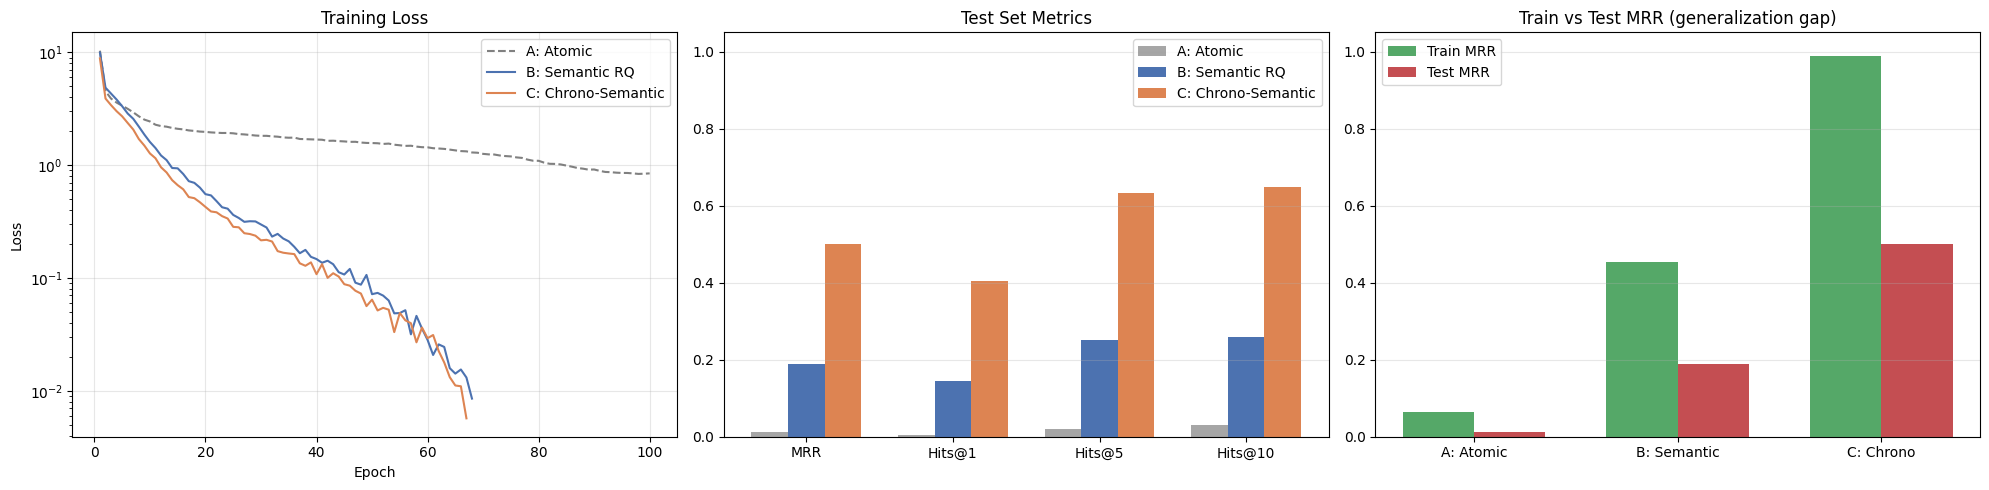

In [ ]:
# ============================================================

# 8B. Visualizations

# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))



# Loss curves

axes[0].plot(range(1, len(loss_a)+1), loss_a, 'gray', linewidth=1.5, label='A: Atomic', linestyle='--')

axes[0].plot(range(1, len(loss_b)+1), loss_b, '#4C72B0', linewidth=1.5, label='B: Semantic RQ')

axes[0].plot(range(1, len(loss_c)+1), loss_c, '#DD8452', linewidth=1.5, label='C: Chrono-Semantic')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[0].set_title('Training Loss'); axes[0].legend()

axes[0].grid(True, alpha=0.3); axes[0].set_yscale('log')



# Test metrics bar chart

metrics = ['MRR', 'Hits@1', 'Hits@5', 'Hits@10']

a_vals = [results_a_test['mrr']] + [results_a_test['hits_at'][k] for k in [1, 5, 10]]

b_vals = [results_b_test['mrr']] + [results_b_test['hits_at'][k] for k in [1, 5, 10]]

c_vals = [results_c_test['mrr']] + [results_c_test['hits_at'][k] for k in [1, 5, 10]]

x = np.arange(len(metrics)); w = 0.25

axes[1].bar(x - w, a_vals, w, label='A: Atomic', color='gray', alpha=0.7)

axes[1].bar(x, b_vals, w, label='B: Semantic RQ', color='#4C72B0')

axes[1].bar(x + w, c_vals, w, label='C: Chrono-Semantic', color='#DD8452')

axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)

axes[1].set_ylim(0, 1.05); axes[1].set_title('Test Set Metrics'); axes[1].legend()

axes[1].grid(True, alpha=0.3, axis='y')



# Train vs test gap (overfitting indicator)

experiments = ['A: Atomic', 'B: Semantic', 'C: Chrono']

train_mrr = [results_a_train['mrr'], results_b_train['mrr'], results_c_train['mrr']]

test_mrr = [results_a_test['mrr'], results_b_test['mrr'], results_c_test['mrr']]

x2 = np.arange(3); w2 = 0.35

axes[2].bar(x2 - w2/2, train_mrr, w2, label='Train MRR', color='#55A868')

axes[2].bar(x2 + w2/2, test_mrr, w2, label='Test MRR', color='#C44E52')

axes[2].set_xticks(x2); axes[2].set_xticklabels(experiments)

axes[2].set_ylim(0, 1.05); axes[2].set_title('Train vs Test MRR (generalization gap)')

axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')



plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 8C. Sample test retrievals — side by side
# ============================================================
print("Sample Test Retrievals (first 10):")
print("=" * 110)

for qid in list(results_a_test['qid_to_query'].keys())[:10]:
    query = results_a_test['qid_to_query'][qid]
    gt = results_a_test['qid_to_doc'][qid]

    def get_top1(results, qid):
        ranked = sorted(results['qid_to_rankdata'][qid].items(), key=lambda x: x[1], reverse=True)
        if ranked and ranked[0][0] == gt:
            return 'OK'
        return 'X '

    ok_a = get_top1(results_a_test, qid)
    ok_b = get_top1(results_b_test, qid)
    ok_c = get_top1(results_c_test, qid)

    print(f"  Q: {query[:80]}")
    print(f"    A[{ok_a}]  B[{ok_b}]  C[{ok_c}]")
    print()

---
## 10. Continual Learning Experiments

### What are we testing?
After training on T0–T15 (20K docs), we introduce T16–T18 (5K new docs) and compare
**Semantic RQ** vs **Chrono-Semantic** DocIDs. The core question: does the temporal task prefix
help the model separate old and new knowledge, reducing catastrophic forgetting?

### Key Metrics

**Backward Transfer (BWT)** — measures *forgetting*.
After learning the new CL documents, how does accuracy on the *old* documents change?

```
BWT = MRR_old_after_CL − MRR_old_before_CL
```
- **BWT = 0**: no forgetting (ideal)
- **BWT < 0**: the model forgot old documents (catastrophic forgetting)
- **BWT > 0**: learning new data actually helped retrieve old data (rare, positive transfer)

**Forward Transfer (FWT)** — measures *new learning capability*.
How well can the model retrieve the *new* CL documents after fine-tuning?

```
FWT = MRR on new docs (T16–T18) after CL training
```
Higher is better — the model can incorporate new knowledge effectively.

### Why compare Semantic RQ vs Chrono-Semantic?
- **Semantic RQ** (Exp B): New docs get RQ codes in the same space as old docs. The model has no signal to distinguish old vs new — forgetting risk is high.
- **Chrono-Semantic** (Exp C): New docs get *new task prefix tokens* (T16, T17, T18). The model can isolate new knowledge in the task-prefix subspace, potentially reducing interference with old knowledge.

### CL Protocol
1. Encode new CL docs with the **same** PCA + RQ codebook (no retraining — ensures consistent semantic space)
2. Assign new task IDs (T16–T18) for chrono prefix
3. Fine-tune existing LoRA on new data only (simplest CL approach — tests raw forgetting)
4. Evaluate on both old (T0–T15) and new (T16–T18) eval queries

In [ ]:
# ============================================================
# 10A. Encode CL documents using saved RQ artifacts
# ============================================================
import pickle

# Load saved PCA + RQ
with open("data/queries/pca_artifact.pkl", "rb") as f:
    cl_pca = pickle.load(f)
cl_rq_index = faiss.read_index("data/queries/rq_index.faiss")
cl_rq = cl_rq_index.rq

# Encode CL documents with the SAME encoder
base_model.to(DEVICE)
base_model.eval()

cl_doc_texts = [(str(row['title']) + '. ' + ' '.join(str(row['content']).split()[:300]))
                for _, row in cl_docs_df.iterrows()]
print(f"Encoding {len(cl_doc_texts)} CL documents...")

cl_embeddings = []
with torch.no_grad():
    for i in range(0, len(cl_doc_texts), 16):
        batch = cl_doc_texts[i:i+16]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt').to(DEVICE)
        enc_out = base_model.get_encoder()(**inputs)
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        pooled = (enc_out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
        cl_embeddings.append(pooled.cpu().float().numpy())

cl_doc_embeddings = np.vstack(cl_embeddings)
base_model.cpu()

# Apply SAME PCA + RQ (consistency with training data)
cl_embeddings_rq = cl_pca.transform(cl_doc_embeddings).astype(np.float32)
cl_unit8_codes = cl_rq.compute_codes(cl_embeddings_rq)

cl_doc_rq_codes = []
for u8_code in cl_unit8_codes:
    bs = faiss.BitstringReader(faiss.swig_ptr(u8_code), cl_unit8_codes.shape[1])
    cl_doc_rq_codes.append([bs.read(RQ_NBITS) for _ in range(NUM_RQ_CODEBOOKS)])

print(f"CL RQ codes: ({len(cl_doc_rq_codes)}, {len(cl_doc_rq_codes[0])})")

# Check collisions between CL codes and training codes
all_rq_strs = set(str(codes) for codes in doc_rq_codes)
cl_collisions_with_train = sum(1 for codes in cl_doc_rq_codes if str(codes) in all_rq_strs)
print(f"CL docs sharing RQ code with train docs: {cl_collisions_with_train}/{len(cl_doc_rq_codes)}")

In [ ]:
# ============================================================
# 10B. Build CL DocIDs and extend mappings
# ============================================================
cl_docid_atomic = {}
cl_docid_rq = {}
cl_docid_chrono = {}

for i, row in cl_docs_df.iterrows():
    doc_id = row['doc_id']
    task_id = row['task_id']

    cl_docid_atomic[doc_id] = [random.randint(0, RQ_CODEBOOK_SIZE - 1) for _ in range(NUM_RQ_CODEBOOKS)]
    cl_docid_rq[doc_id] = list(cl_doc_rq_codes[i])
    cl_docid_chrono[doc_id] = [task_id] + list(cl_doc_rq_codes[i])

# Merge with training DocIDs for combined evaluation
all_tokenids_atomic = {**tokenids_atomic, **{doc_id: to_tokenids_atomic(codes) for doc_id, codes in cl_docid_atomic.items()}}
all_tokenids_rq = {**tokenids_rq, **{doc_id: to_tokenids_rq(codes) for doc_id, codes in cl_docid_rq.items()}}
all_tokenids_chrono = {**tokenids_chrono, **{doc_id: to_tokenids_chrono(codes[0], codes[1:]) for doc_id, codes in cl_docid_chrono.items()}}

# CL queries
cl_train_queries = df[(df['split'] == 'train') & (df['phase'] == 'cl')].reset_index(drop=True)
cl_test_queries = df[(df['split'] == 'eval') & (df['phase'] == 'cl')].reset_index(drop=True)

print(f"CL train queries: {len(cl_train_queries):,}")
print(f"CL test queries:  {len(cl_test_queries):,}")
print(f"Combined corpus: {len(all_tokenids_atomic):,} docs")


In [ ]:
# ============================================================
# 10C. CL Training — Fine-tune on new data (Semantic RQ vs Chrono-Semantic)
# ============================================================
# Strategy: Continue training existing LoRA on CL data only.
# This is the simplest CL approach — no replay, no regularization.
# It tests raw forgetting: which DocID scheme is more resilient?

def run_cl_experiment(exp_letter, base_checkpoint, cl_tokenids, all_tokenids, docid_length, label):
    """Load base model, fine-tune on CL data, evaluate on old + new."""
    print(f"\n{'='*60}")
    print(f"  CL: {label}")
    print(f"{'='*60}")

    # Load saved base model checkpoint
    model = create_fresh_model()
    model.load_state_dict(torch.load(base_checkpoint, map_location=DEVICE))
    print(f"  Loaded checkpoint: {base_checkpoint}")

    # CL training dataset (only new docs)
    cl_train_ds = DocIDDataset(cl_train_queries, {doc_id: all_tokenids[doc_id] for doc_id in cl_tokenids}, "CL Train")
    cl_collator = DocIDCollator(tokenizer, DECODER_START_ID, MAX_QUERY_LEN)
    cl_loader = DataLoader(cl_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=cl_collator)

    # Train on CL data (fewer epochs — these are new docs added to existing knowledge)
    cl_loss = train_experiment(model, cl_loader, docid_length, label=f"CL {label}")

    # Build combined trie (old + new docs)
    _, combined_prefixer, combined_smtid = build_prefix_trie(all_tokenids, DECODER_START_ID)

    # Evaluate on OLD test queries (measure forgetting / BWT)
    # Sample 1000 ground-truth queries from old docs
    old_eval_sample = test_queries_df.sample(min(EVAL_SAMPLE, len(test_queries_df)), random_state=SEED)
    print(f"\n--- Old docs (T0-T15) evaluation → measures BWT ({len(old_eval_sample)} queries) ---")
    old_test_ds = DocIDDataset(old_eval_sample, all_tokenids, "Old Test")
    results_old = evaluate_experiment(model, old_test_ds, combined_prefixer, combined_smtid,
                                      docid_length, f"CL {label} — Old Docs")

    # Evaluate on NEW test queries (measure FWT)
    # Sample up to 1000 ground-truth queries from new docs
    new_eval_sample = cl_test_queries.sample(min(EVAL_SAMPLE, len(cl_test_queries)), random_state=SEED)
    print(f"\n--- New docs (T16-T18) evaluation → measures FWT ({len(new_eval_sample)} queries) ---")
    new_test_ds = DocIDDataset(new_eval_sample, all_tokenids, "New Test")
    results_new = evaluate_experiment(model, new_test_ds, combined_prefixer, combined_smtid,
                                      docid_length, f"CL {label} — New Docs")

    model.cpu()
    gc.collect()
    torch.cuda.empty_cache() if DEVICE == 'cuda' else None

    return cl_loss, results_old, results_new

# Run CL for Semantic RQ and Chrono-Semantic only (Atomic is just a baseline, not relevant for CL comparison)
print("=" * 60)
print("  Running CL for Exp B (Semantic RQ) and Exp C (Chrono-Semantic)")
print("=" * 60)

cl_loss_b, cl_old_b, cl_new_b = run_cl_experiment("B", "model_expb_base.pt",
    cl_docid_rq, all_tokenids_rq, DOCID_LEN_RQ, "Semantic RQ")

cl_loss_c, cl_old_c, cl_new_c = run_cl_experiment("C", "model_expc_base.pt",
    cl_docid_chrono, all_tokenids_chrono, DOCID_LEN_CHRONO, "Chrono-Semantic")

---
## 11. Continual Learning Analysis

### Metrics Recap

| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **BWT** (Backward Transfer) | `MRR_old_after_CL − MRR_old_before_CL` | How much the model *forgot* old documents. Negative = forgetting. |
| **FWT** (Forward Transfer) | `MRR_new_after_CL` | How well the model learned the *new* documents. Higher = better. |

### What we expect
- **Semantic RQ**: Should show **more forgetting** (lower BWT) because new docs have codes in the same space — training on them overwrites old associations.
- **Chrono-Semantic**: Should show **less forgetting** (higher BWT) because the task prefix gives the model a routing signal — it can learn new task prefixes without disturbing old ones.

In [ ]:
# ============================================================
# 11A. CL Metrics Summary — Semantic RQ vs Chrono-Semantic
# ============================================================
print(f"{'='*90}")
print(f"  CONTINUAL LEARNING: Semantic RQ (B) vs Chrono-Semantic (C)")
print(f"{'='*90}")

cl_data = {
    'B (Semantic RQ)': {
        'base_test_mrr': results_b_test['mrr'],
        'cl_old_mrr': cl_old_b['mrr'],
        'cl_new_mrr': cl_new_b['mrr'],
        'base_test_h1': results_b_test['hits_at'][1],
        'cl_old_h1': cl_old_b['hits_at'][1],
        'cl_new_h1': cl_new_b['hits_at'][1],
        'base_test_h5': results_b_test['hits_at'][5],
        'cl_old_h5': cl_old_b['hits_at'][5],
        'cl_new_h5': cl_new_b['hits_at'][5],
    },
    'C (Chrono-Sem)': {
        'base_test_mrr': results_c_test['mrr'],
        'cl_old_mrr': cl_old_c['mrr'],
        'cl_new_mrr': cl_new_c['mrr'],
        'base_test_h1': results_c_test['hits_at'][1],
        'cl_old_h1': cl_old_c['hits_at'][1],
        'cl_new_h1': cl_new_c['hits_at'][1],
        'base_test_h5': results_c_test['hits_at'][5],
        'cl_old_h5': cl_old_c['hits_at'][5],
        'cl_new_h5': cl_new_c['hits_at'][5],
    },
}

print(f"\n{'Metric':<20} {'B: Semantic RQ':>16} {'C: Chrono-Sem':>16} {'C − B':>10}")
print("-" * 65)

for metric_label, base_key, old_key, new_key, fmt in [
    ("Base MRR (old)", 'base_test_mrr', None, None, '.4f'),
    ("After CL MRR (old)", None, 'cl_old_mrr', None, '.4f'),
    ("BWT (forgetting)", None, None, None, '+.4f'),  # computed
    ("FWT (new docs MRR)", None, None, 'cl_new_mrr', '.4f'),
    ("Base Hits@1 (old)", 'base_test_h1', None, None, '.1%'),
    ("After CL H@1 (old)", None, 'cl_old_h1', None, '.1%'),
    ("FWT Hits@1 (new)", None, None, 'cl_new_h1', '.1%'),
]:
    if metric_label == "BWT (forgetting)":
        b_val = cl_data['B (Semantic RQ)']['cl_old_mrr'] - cl_data['B (Semantic RQ)']['base_test_mrr']
        c_val = cl_data['C (Chrono-Sem)']['cl_old_mrr'] - cl_data['C (Chrono-Sem)']['base_test_mrr']
    else:
        key = base_key or old_key or new_key
        b_val = cl_data['B (Semantic RQ)'][key]
        c_val = cl_data['C (Chrono-Sem)'][key]

    diff = c_val - b_val
    if fmt == '.1%':
        print(f"{metric_label:<20} {b_val:>15.1%} {c_val:>15.1%}  {'+' if diff>=0 else ''}{diff:>8.1%}")
    elif fmt == '+.4f':
        print(f"{metric_label:<20} {b_val:>+15.4f} {c_val:>+15.4f}  {'+' if diff>=0 else ''}{diff:>8.4f}")
    else:
        print(f"{metric_label:<20} {b_val:>15.4f} {c_val:>15.4f}  {'+' if diff>=0 else ''}{diff:>8.4f}")

print(f"\n{'='*65}")
print("BWT < 0 means forgetting. Less negative = better.")
print("FWT = accuracy on new docs. Higher = better.")
print("C − B > 0 means Chrono-Semantic outperforms Semantic RQ.")

In [ ]:
# ============================================================
# 11B. Forgetting Visualization — Semantic RQ vs Chrono-Semantic
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

experiments = ['B: Semantic RQ', 'C: Chrono-Semantic']
exp_keys = ['B (Semantic RQ)', 'C (Chrono-Sem)']

# --- Plot 1: Base vs After-CL MRR ---
base_mrr = [cl_data[k]['base_test_mrr'] for k in exp_keys]
old_mrr = [cl_data[k]['cl_old_mrr'] for k in exp_keys]
new_mrr = [cl_data[k]['cl_new_mrr'] for k in exp_keys]

x = np.arange(2); w = 0.25
axes[0].bar(x - w, base_mrr, w, label='Before CL (old docs)', color='#55A868')
axes[0].bar(x, old_mrr, w, label='After CL (old docs)', color='#C44E52')
axes[0].bar(x + w, new_mrr, w, label='After CL (new docs)', color='#4C72B0')
axes[0].set_xticks(x); axes[0].set_xticklabels(experiments)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('MRR')
axes[0].set_title('CL Impact: Old vs New Document Retrieval')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# --- Plot 2: BWT comparison ---
bwt_vals = [old - base for old, base in zip(old_mrr, base_mrr)]
colors_bwt = ['#C44E52' if v < 0 else '#55A868' for v in bwt_vals]
bars = axes[1].bar(experiments, bwt_vals, color=colors_bwt, edgecolor='white', width=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('BWT (MRR change)')
axes[1].set_title('Backward Transfer\n(negative = forgetting, closer to 0 = better)')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, bwt_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:+.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')

# --- Plot 3: CL training loss ---
axes[2].plot(range(1, len(cl_loss_b)+1), cl_loss_b, '#4C72B0', linewidth=2, label='B: Semantic RQ')
axes[2].plot(range(1, len(cl_loss_c)+1), cl_loss_c, '#DD8452', linewidth=2, label='C: Chrono-Semantic')
axes[2].set_xlabel('CL Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('CL Training Loss\n(learning new T16–T18 documents)')
axes[2].legend(); axes[2].grid(True, alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout(); plt.show()

# --- Summary verdict ---
bwt_b = cl_data['B (Semantic RQ)']['cl_old_mrr'] - cl_data['B (Semantic RQ)']['base_test_mrr']
bwt_c = cl_data['C (Chrono-Sem)']['cl_old_mrr'] - cl_data['C (Chrono-Sem)']['base_test_mrr']
print(f"\n--- CL Verdict ---")
print(f"Semantic RQ  BWT: {bwt_b:+.4f} | FWT: {cl_data['B (Semantic RQ)']['cl_new_mrr']:.4f}")
print(f"Chrono-Sem   BWT: {bwt_c:+.4f} | FWT: {cl_data['C (Chrono-Sem)']['cl_new_mrr']:.4f}")
if bwt_c > bwt_b:
    print(f"→ Chrono-Semantic forgets LESS ({bwt_c - bwt_b:+.4f} BWT advantage)")
else:
    print(f"→ Semantic RQ forgets LESS ({bwt_b - bwt_c:+.4f} BWT advantage)")

---
## 12. Summary

In [ ]:
# ============================================================
# 12. Final Summary
# ============================================================
print("=" * 90)
print("  DSI-CL 25K BBC NEWS — FINAL RESULTS")
print("=" * 90)

print(f"\nDataset: BBC News AllTime, {len(docs_df):,} train + {len(cl_docs_df):,} CL docs")
print(f"Model: {MODEL_NAME}")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, lr={LEARNING_RATE}")
print(f"RQ: {NUM_RQ_CODEBOOKS} codebooks x {RQ_CODEBOOK_SIZE} centroids ({RQ_NBITS} bits)")

print(f"\n{'--- BASE TRAINING (T0-T15) ---':^60}")
for name, loss, r_train, r_test in [
    ("A: Atomic", loss_a, results_a_train, results_a_test),
    ("B: Semantic RQ", loss_b, results_b_train, results_b_test),
    ("C: Chrono-Semantic", loss_c, results_c_train, results_c_test),
]:
    print(f"  {name:20s} | Loss: {loss[-1]:.4f} | Train MRR: {r_train['mrr']:.4f} | Test MRR: {r_test['mrr']:.4f} | Test H@1: {r_test['hits_at'][1]:.1%}")

print(f"\n{'--- CONTINUAL LEARNING (T16-T18): Semantic RQ vs Chrono-Semantic ---':^60}")
bwt_b = cl_data['B (Semantic RQ)']['cl_old_mrr'] - cl_data['B (Semantic RQ)']['base_test_mrr']
bwt_c = cl_data['C (Chrono-Sem)']['cl_old_mrr'] - cl_data['C (Chrono-Sem)']['base_test_mrr']

for name, key in [('B: Semantic RQ', 'B (Semantic RQ)'), ('C: Chrono-Semantic', 'C (Chrono-Sem)')]:
    d = cl_data[key]
    bwt = d['cl_old_mrr'] - d['base_test_mrr']
    print(f"  {name:20s} | BWT: {bwt:+.4f} | Old MRR: {d['cl_old_mrr']:.4f} | FWT MRR: {d['cl_new_mrr']:.4f} | FWT H@1: {d['cl_new_h1']:.1%}")

print(f"\n  BWT = Backward Transfer (forgetting). Negative = model forgot old docs.")
print(f"  FWT = Forward Transfer (new learning). Higher = model learned new docs well.")
if bwt_c > bwt_b:
    print(f"\n  → Chrono-Semantic shows {bwt_c - bwt_b:+.4f} less forgetting than Semantic RQ")
else:
    print(f"\n  → Semantic RQ shows {bwt_b - bwt_c:+.4f} less forgetting than Chrono-Semantic")

print(f"\n{'='*90}")